Imagem redimensionada para: 640x480 pixels
Normalização aplicada: pixels ajustados para [0, 255]


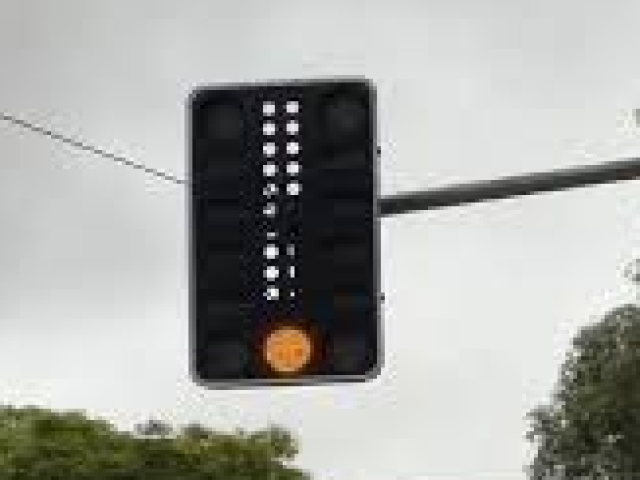

In [507]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# CARREGAMENTO DA IMAGEM
# Lê a imagem do caminho especificado usando OpenCV.
# cv2.imread retorna um array numpy no formato BGR (Blue, Green, Red).

img = cv2.imread("/content/sample_data/1.png") # lembrar de mudar o tipo da imagem na hora de testar (.png, .jpeg, .jpg, .webp)

# Verifica se a imagem foi carregada corretamente
if img is None:
    raise FileNotFoundError("Imagem não encontrada. Verifique o caminho do arquivo.")


# PRÉ-PROCESSAMENTO: REDIMENSIONAMENTO PARA 640x480
# Redimensionar padroniza a entrada e melhora a performance.
img = cv2.resize(img, (640, 480), interpolation=cv2.INTER_AREA)
print(f"Imagem redimensionada para: {img.shape[1]}x{img.shape[0]} pixels")

# PRÉ-PROCESSAMENTO: NORMALIZAÇÃO DA IMAGEM
# Normaliza os valores dos pixels para o intervalo [0, 255].
# Isso melhora o contraste e padroniza a iluminação da imagem,
# tornando a detecção de cores mais robusta.
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
print("Normalização aplicada: pixels ajustados para [0, 255]")

# Cópias da imagem para uso posterior (evita modificar o original)
gray = img.copy()    # será convertida para escala de cinza
output = img.copy()  # será usada para desenhar o resultado final

cv2_imshow(img)

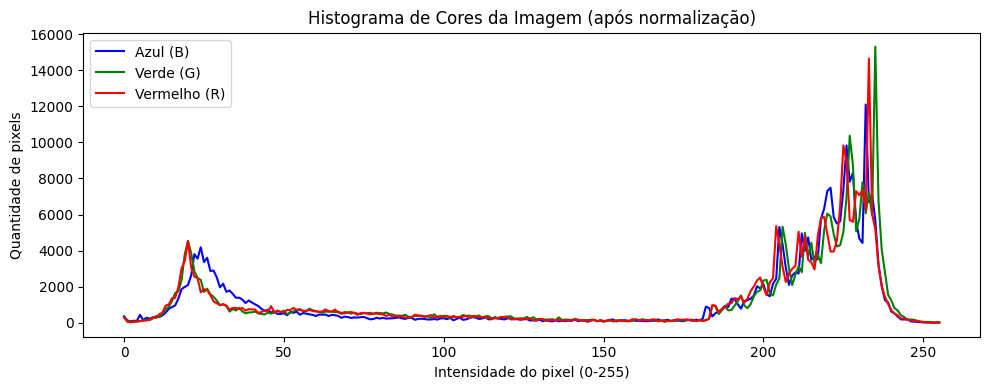

Histograma gerado com sucesso.


In [508]:
# ANÁLISE DE HISTOGRAMA
# O histograma mostra a distribuição de intensidade de cada canal
# de cor (Azul, Verde, Vermelho). Isso é útil para entender a
# composição de cores da imagem antes da detecção.

cores = ('b', 'g', 'r')
nomes_canais = ('Azul (B)', 'Verde (G)', 'Vermelho (R)')

plt.figure(figsize=(10, 4))
plt.title("Histograma de Cores da Imagem (após normalização)")

for i, (cor, nome) in enumerate(zip(cores, nomes_canais)):
    # calcHist(imagens, canais, máscara, tamanho_bins, intervalo)
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=cor, label=nome)

plt.xlabel("Intensidade do pixel (0-255)")
plt.ylabel("Quantidade de pixels")
plt.legend()
plt.tight_layout()
plt.show()
print("Histograma gerado com sucesso.")

In [509]:
# CONVERSÃO PARA HSV
# O espaço de cores HSV (Hue, Saturation, Value) separa a
# informação de cor (matiz) da luminosidade, tornando a
# detecção de cores muito mais robusta a variações de iluminação
# do que o espaço RGB padrão.

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [510]:
# DEFINIÇÃO DOS INTERVALOS DE COR (em HSV)
# Cada cor do semáforo (vermelho, amarelo, verde) tem um intervalo
# específico no espaço HSV.
# O vermelho aparece em dois intervalos no HSV (próximo a 0° e 180°)
# pois envolve a "volta" do círculo de matiz.
# Formato: np.array([Hue_min, Saturation_min, Value_min])

# Vermelho - faixa 1 (0 a 10 graus de matiz)
lower_red1 = np.array([0, 120, 80])
upper_red1 = np.array([10, 255, 255])

# Vermelho - faixa 2 (170 a 180 graus de matiz)
lower_red2 = np.array([170, 120, 80])
upper_red2 = np.array([180, 255, 255])

# Amarelo (10 a 40 graus de matiz)
lower_yellow = np.array([10, 120, 100])
upper_yellow = np.array([40, 255, 255])

# Verde (40 a 90 graus de matiz)
lower_green = np.array([40, 100, 70])
upper_green = np.array([90, 255, 255])

Máscara Vermelha:


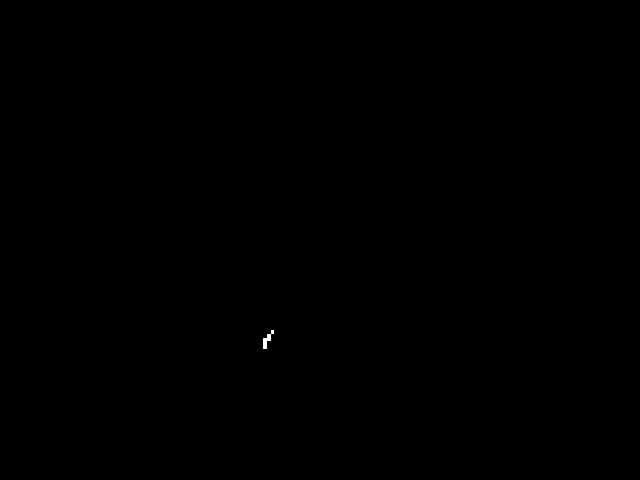

Máscara Amarela:


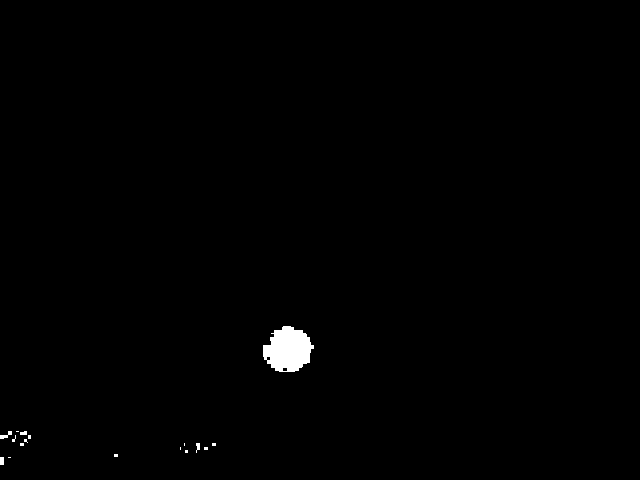

Máscara Verde:


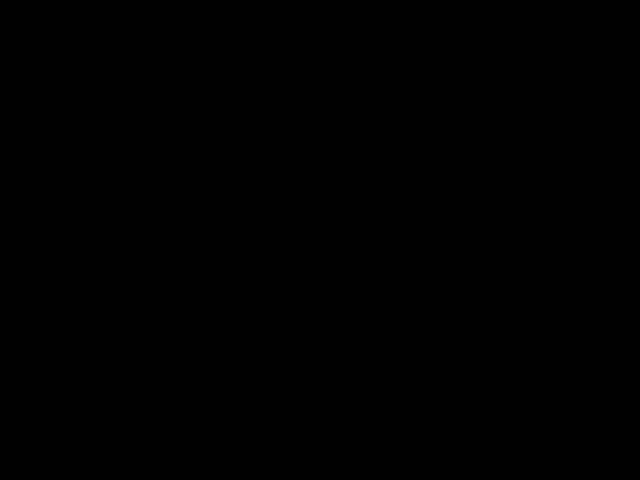

In [511]:
# CRIAÇÃO DAS MÁSCARAS DE COR
# cv2.inRange cria uma imagem binária (preto e branco) onde:
# - pixels BRANCOS (255) = cor está dentro do intervalo definido
# - pixels PRETOS (0)    = cor está fora do intervalo
# As duas máscaras de vermelho são combinadas com adição.

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)      # vermelho faixa 1
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)      # vermelho faixa 2

mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)  # amarelo
mask_green  = cv2.inRange(hsv, lower_green, upper_green)    # verde

# Une as duas máscaras de vermelho em uma só
mask_red = mask1 + mask2

# Exibe as máscaras para visualização
print("Máscara Vermelha:")
cv2_imshow(mask_red)
print("Máscara Amarela:")
cv2_imshow(mask_yellow)
print("Máscara Verde:")
cv2_imshow(mask_green)

In [512]:

# DETECÇÃO DE CONTORNOS NAS MÁSCARAS
# cv2.findContours percorre a imagem binária e retorna uma lista
# de contornos (bordas) dos objetos brancos encontrados.
# RETR_TREE recupera todos os contornos em hierarquia.
# CHAIN_APPROX_SIMPLE comprime segmentos horizontais/verticais.

contours_red, _    = cv2.findContours(mask_red,    cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_yellow, _ = cv2.findContours(mask_yellow, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours_green, _  = cv2.findContours(mask_green,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

print(f"Contornos encontrados - Vermelho: {len(contours_red)}, Amarelo: {len(contours_yellow)}, Verde: {len(contours_green)}")

Contornos encontrados - Vermelho: 1, Amarelo: 19, Verde: 0


--- Verificando contornos VERMELHOS ---
--- Verificando contornos AMARELOS ---
  Circularidade: 0.603
  → Possível círculo detectado
--- Verificando contornos VERDES ---


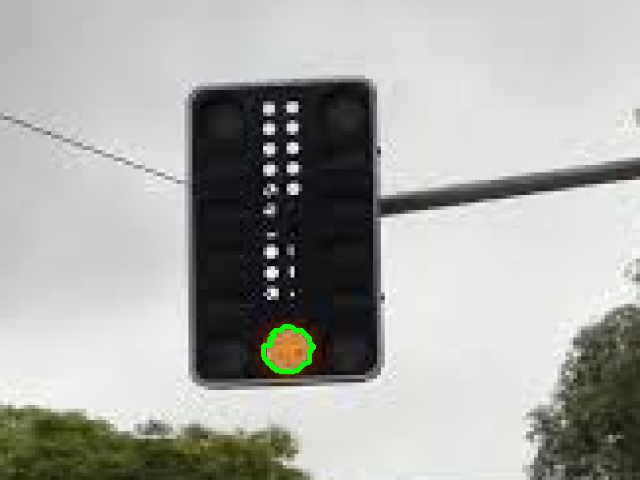

In [513]:

# VERIFICAÇÃO DE CIRCULARIDADE E DESENHO DOS CONTORNOS
# A circularidade mede o quão próximo de um círculo perfeito
# é um contorno. Valor 1.0 = círculo perfeito.
# Fórmula: 4π × Área / Perímetro²
# Usada para identificar as luzes circulares do semáforo.

def verificar_circulo(contorno, img_destino, area_minima=400, circularidade_minima=0.5):
    """Verifica se um contorno é circular e, se for, desenha na imagem."""
    area = cv2.contourArea(contorno)

    # Ignora contornos muito pequenos (ruído)
    if area < area_minima:
        return False

    perimetro = cv2.arcLength(contorno, True)

    # Evita divisão por zero
    if perimetro == 0:
        return False

    # Cálculo da circularidade
    circularidade = (4 * np.pi * area) / (perimetro * perimetro)
    print(f"  Circularidade: {circularidade:.3f}")

    if circularidade > circularidade_minima:
        print("  → Possível círculo detectado")
        # Desenha o contorno detectado na imagem (em verde)
        cv2.drawContours(img_destino, [contorno], -1, (0, 255, 0), 3)
        return True
    return False


# Aplica a verificação de circularidade em cada cor
print("--- Verificando contornos VERMELHOS ---")
for cnt in contours_red:
    verificar_circulo(cnt, img)

print("--- Verificando contornos AMARELOS ---")
for cnt in contours_yellow:
    verificar_circulo(cnt, img)

print("--- Verificando contornos VERDES ---")
for cnt in contours_green:
    verificar_circulo(cnt, img)

cv2_imshow(img)

In [514]:

# CÁLCULO DOS CENTROS DOS CÍRCULOS DETECTADOS
# Para cada contorno aprovado (área suficiente e formato quadrado),
# calcula o centro geométrico do círculo detectado.
# Esses centros serão usados para verificar alinhamento vertical,
# característica essencial de um semáforo.

centros = []

def extrair_centros(contornos, cor_nome):
    """Extrai e adiciona os centros dos círculos detectados à lista global."""
    for cnt in contornos:
        area = cv2.contourArea(cnt)

        # Filtra contornos com área mínima
        if area > 140:
            # Retângulo delimitador ao redor do contorno
            (x, y, w, h) = cv2.boundingRect(cnt)

            # Razão largura/altura: próximo de 1.0 indica formato circular
            ratio = w / float(h)

            if 0.8 < ratio < 1.2:
                cx = x + w // 2
                cy = y + h // 2
                centros.append((cx, cy))
                print(f"  Centro {cor_nome}: ({cx}, {cy})")

print("--- Centros Vermelhos ---")
extrair_centros(contours_red, "vermelho")

print("--- Centros Amarelos ---")
extrair_centros(contours_yellow, "amarelo")

print("--- Centros Verdes ---")
extrair_centros(contours_green, "verde")

print(f"\nTotal de centros detectados: {len(centros)}")

--- Centros Vermelhos ---
--- Centros Amarelos ---
  Centro amarelo: (288, 349)
--- Centros Verdes ---

Total de centros detectados: 1


In [515]:

# VERIFICAÇÃO DE ALINHAMENTO VERTICAL
# Semáforos têm suas luzes empilhadas verticalmente.
# Este trecho verifica se dois ou mais centros detectados
# estão alinhados na mesma coluna (diferença horizontal < 20px),
# o que é um forte indicativo da presença de um semáforo.

alinhamentoVertical = 0

for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        x1, y1 = centros[i]
        x2, y2 = centros[j]

        # Se a diferença horizontal entre os centros for pequena,
        # considera-se que estão alinhados verticalmente
        if abs(x1 - x2) < 20:
            alinhamentoVertical += 1
            print(f"  Alinhamento vertical detectado entre ({x1},{y1}) e ({x2},{y2})")

print(f"\nTotal de alinhamentos verticais: {alinhamentoVertical}")


Total de alinhamentos verticais: 0


In [516]:

# BINARIZAÇÃO DA MÁSCARA VERMELHA
# cv2.threshold limpa a máscara, garantindo que só existam
# valores 0 ou 255 (sem valores intermediários que poderiam
# causar ruído na detecção de bordas).

_, mask_red_bin = cv2.threshold(mask_red, 127, 255, cv2.THRESH_BINARY)
# Nota: o resultado é armazenado em mask_red_bin (o original era descartado)

In [517]:

# PRÉ-PROCESSAMENTO PARA DETECÇÃO DE LINHAS
# 1. Converte para escala de cinza: reduz de 3 canais para 1
# 2. GaussianBlur: suaviza a imagem, removendo ruídos de alta
#    frequência que poderiam gerar falsas detecções de bordas
# 3. Canny: detecta bordas usando gradiente de intensidade

gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)   # converte para cinza
gray = cv2.GaussianBlur(gray, (7, 7), 0)         # suaviza a imagem

# Detecção de bordas com Canny (thresholds: 50=fraco, 150=forte)
edges = cv2.Canny(gray, 50, 150)

Bordas detectadas (após dilatação):


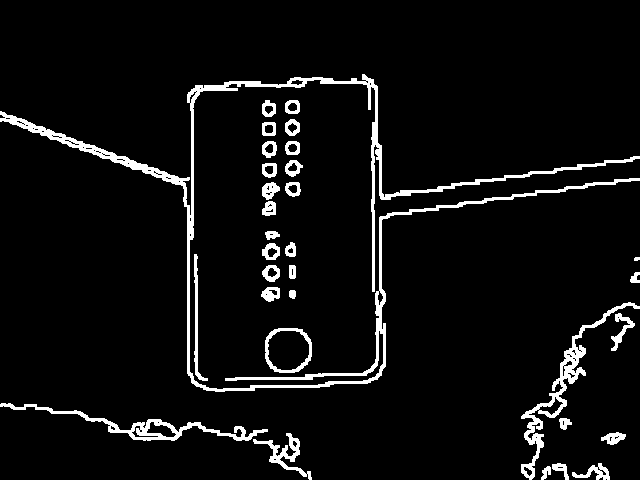

In [518]:

# DILATAÇÃO DAS BORDAS
# Expande ligeiramente as bordas detectadas usando um kernel 3x3.
# Isso conecta bordas próximas que podem ter ficado separadas,
# melhorando a detecção de linhas pelo algoritmo Hough.

kernel = np.ones((3, 3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

print("Bordas detectadas (após dilatação):")
cv2_imshow(edges)

In [519]:

# DETECÇÃO DE LINHAS COM TRANSFORMADA DE HOUGH PROBABILÍSTICA
# HoughLinesP detecta segmentos de linha na imagem de bordas.
# Parâmetros:
# - rho=1: resolução em pixels
# - theta=π/180: resolução angular (1 grau)
# - threshold=100: votos mínimos para considerar uma linha
# - minLineLength=100: tamanho mínimo do segmento (pixels)
# - maxLineGap=10: espaço máximo entre pontos da mesma linha

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=100,
    minLineLength=100,
    maxLineGap=10
)

# Lista que armazenará apenas as linhas com orientação vertical
vertical_lines = []

Linhas verticais encontradas: 12
[(np.int32(194), np.int32(254), np.int32(196), np.int32(386)), (np.int32(187), np.int32(369), np.int32(189), np.int32(205)), (np.int32(187), np.int32(373), np.int32(189), np.int32(256)), (np.int32(191), np.int32(239), np.int32(193), np.int32(88)), (np.int32(372), np.int32(291), np.int32(372), np.int32(122)), (np.int32(373), np.int32(291), np.int32(373), np.int32(122)), (np.int32(262), np.int32(104), np.int32(272), np.int32(214)), (np.int32(273), np.int32(214), np.int32(273), np.int32(103)), (np.int32(374), np.int32(291), np.int32(374), np.int32(122)), (np.int32(274), np.int32(214), np.int32(274), np.int32(103)), (np.int32(275), np.int32(214), np.int32(275), np.int32(104)), (np.int32(187), np.int32(312), np.int32(188), np.int32(209))]


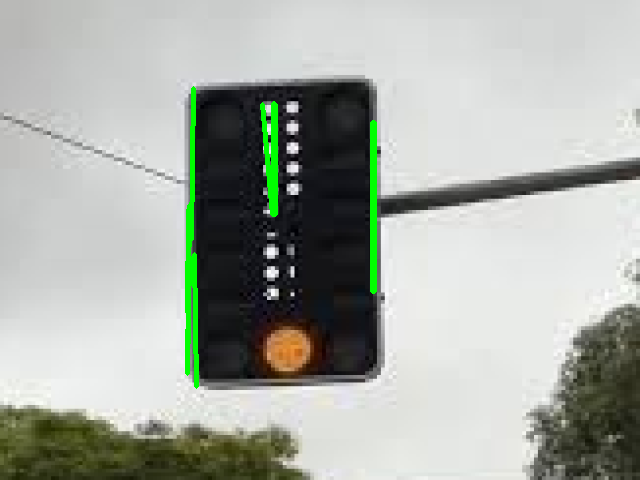

In [520]:
# FILTRAGEM DE LINHAS VERTICAIS
# Das linhas detectadas, mantém apenas as que são verticais
# (diferença horizontal entre os extremos < 20 pixels).
# Linhas verticais indicam a lateral do poste do semáforo.

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]

        # Verifica se a linha é aproximadamente vertical
        if abs(x1 - x2) < 20:
            vertical_lines.append((x1, y1, x2, y2))

            # Desenha a linha vertical na imagem de saída (em verde)
            cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 3)

print(f"Linhas verticais encontradas: {len(vertical_lines)}")
print(vertical_lines)

cv2_imshow(output)

POSSÍVEL SEMÁFORO detectado pela caixa delimitadora


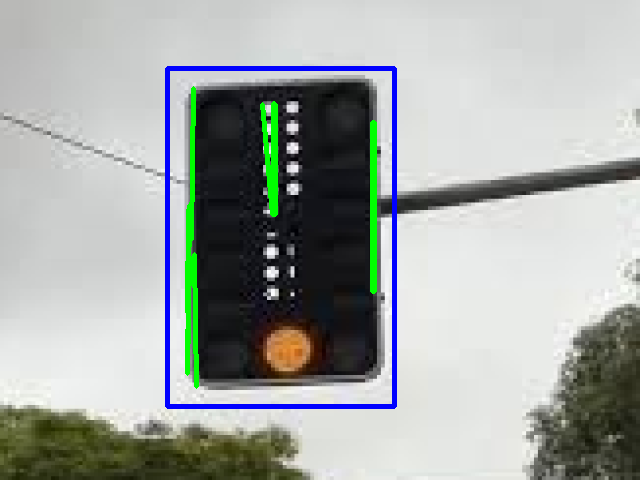

In [521]:
# CÁLCULO DA CAIXA DELIMITADORA DO POSSÍVEL SEMÁFORO
# Se pelo menos 2 linhas verticais foram encontradas,
# calcula o retângulo que engloba todas elas (com margem).
# Essa caixa representa a região onde o semáforo pode estar.
if len(vertical_lines) >= 2:

    xs = []  # coordenadas X de todas as extremidades
    ys = []  # coordenadas Y de todas as extremidades

    for (x1, y1, x2, y2) in vertical_lines:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    # Limites da caixa delimitadora
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    # Adiciona uma margem ao redor da caixa
    padding = 20
    min_x -= padding
    max_x += padding
    min_y -= padding
    max_y += padding

    # Desenha a caixa delimitadora na imagem de saída (em azul)
    cv2.rectangle(output, (min_x, min_y), (max_x, max_y), (255, 0, 0), 4)
    print("POSSÍVEL SEMÁFORO detectado pela caixa delimitadora")

cv2_imshow(output)

  Centro (288, 349) - dentro_x: True, dentro_y: True

Total de círculos dentro da caixa: 1
Caixa: x=167, y=68, w=227, h=338


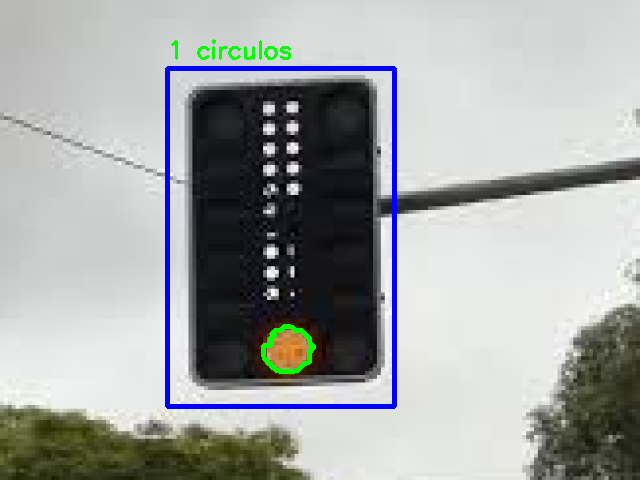

In [522]:
# CONTAGEM DE CÍRCULOS DENTRO DA CAIXA DELIMITADORA
# Verifica quantos dos centros detectados anteriormente estão
# dentro da caixa delimitadora do possível semáforo.
# Quanto mais círculos coloridos dentro da caixa, maior a
# confiança de que é um semáforo.

# Inicializa contador e posição padrão do texto
contador = 0
x, y = 10, 10  # posição padrão caso não haja caixa delimitadora

if len(vertical_lines) >= 2:

    # Dimensões da caixa
    w = max_x - min_x
    h = max_y - min_y

    # Verifica quais centros de círculos estão dentro da caixa
    for (cx, cy) in centros:
        dentro_x = min_x < cx < max_x
        dentro_y = min_y < cy < max_y
        print(f"  Centro ({cx}, {cy}) - dentro_x: {dentro_x}, dentro_y: {dentro_y}")

        if dentro_x and dentro_y:
            contador += 1

    print(f"\nTotal de círculos dentro da caixa: {contador}")

    # Desenha a caixa delimitadora na imagem principal (em azul)
    cv2.rectangle(img, (min_x, min_y), (max_x, max_y), (255, 0, 0), 4)

    # Escreve o número de círculos detectados acima da caixa
    cv2.putText(
        img,
        f"{contador} circulos",
        (min_x, min_y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    print(f"Caixa: x={min_x}, y={min_y}, w={w}, h={h}")

    # Atualiza posição para o texto final
    x, y = min_x, min_y

# Exibe resultado com caixa e contagem
cv2_imshow(img)

✅ SEMÁFORO DETECTADO


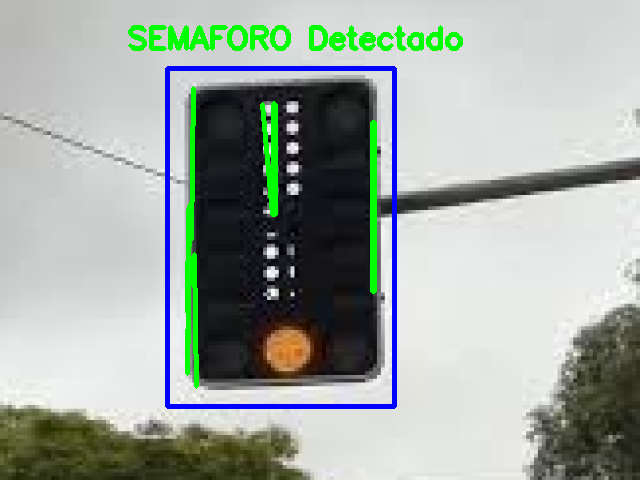

In [523]:
# RESULTADO FINAL: SEMÁFORO DETECTADO OU NÃO
# Se pelo menos 1 círculo colorido foi encontrado dentro
# da caixa delimitadora, o semáforo é considerado detectado.
# O resultado é exibido na imagem de saída com texto.
if contador >= 1:
    print("✅ SEMÁFORO DETECTADO")

    # Escreve mensagem de detecção na imagem de saída (texto verde)
    cv2.putText(
        output,
        "SEMAFORO Detectado",
        (x - 40, y - 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        3
    )
else:
    print("❌ Nenhum semáforo detectado")

    # Escreve mensagem de ausência na imagem de saída (texto vermelho)
    cv2.putText(
        output,
        "sem semaforo",
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        3
    )

# Exibe a imagem final com o resultado
cv2_imshow(output)